In [4]:
import pandas as pd


In [5]:
import numpy as np


In [6]:
df = pd.read_csv('https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/master/2014-15_To_2016-17_School-_Level_NYC_Regents_Report_For_All_Variables.csv')

In [7]:
df

,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
0,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Common Core Algebra,2017,4,s,s,s,s,s,s,s,na,na
1,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2015,16,77.9,1,6.3,15,93.8,7,43.8,na,na
2,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2016,9,74,1,11.1,8,88.9,2,22.2,na,na
3,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2016,3,s,s,s,s,s,s,s,na,na
4,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2017,2,s,s,s,s,s,s,s,na,na
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212326,84X717,Icahn Charter School,K-8,Living Environment,2016,8,s,s,s,s,s,s,s,na,na
212327,84X717,Icahn Charter School,K-8,Living Environment,2016,5,s,s,s,s,s,s,s,na,na
212328,84X717,Icahn Charter School,K-8,Living Environment,2017,6,s,s,s,s,s,s,s,na,na
212329,84X717,Icahn Charter School,K-8,Living Environment,2017,4,s,s,s,s,s,s,s,na,na


In [8]:
df.isnull().sum()

,0
School DBN,0
School Name,0
School Level,0
Regents Exam,10
Year,0
Total Tested,0
Mean Score,0
Number Scoring Below 65,0
Percent Scoring Below 65,0
Number Scoring 65 or Above,0


In [9]:
#drop columns with missing values
df.dropna()

,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
0,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Common Core Algebra,2017,4,s,s,s,s,s,s,s,na,na
1,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2015,16,77.9,1,6.3,15,93.8,7,43.8,na,na
2,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2016,9,74,1,11.1,8,88.9,2,22.2,na,na
3,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2016,3,s,s,s,s,s,s,s,na,na
4,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2017,2,s,s,s,s,s,s,s,na,na
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212326,84X717,Icahn Charter School,K-8,Living Environment,2016,8,s,s,s,s,s,s,s,na,na
212327,84X717,Icahn Charter School,K-8,Living Environment,2016,5,s,s,s,s,s,s,s,na,na
212328,84X717,Icahn Charter School,K-8,Living Environment,2017,6,s,s,s,s,s,s,s,na,na
212329,84X717,Icahn Charter School,K-8,Living Environment,2017,4,s,s,s,s,s,s,s,na,na


some columns have "s" value which is stopping the datatype from being numerical, they need to be dropped.

Below you'll see i went back to the top and imported numpy as np to do the conversion.


In [10]:
# @title
import numpy as np

# Identify score columns that are currently objects but should be numeric
score_columns_to_clean = [
    'Mean Score', 'Number Scoring Below 65', 'Percent Scoring Below 65',
    'Number Scoring 65 or Above', 'Percent Scoring 65 or Above',
    'Number Scoring 80 or Above', 'Percent Scoring 80 or Above',
    'Number Scoring CR', 'Percent Scoring CR'
]

# Replace 's' and 'na' values with NaN in these columns
for col in score_columns_to_clean:
    df[col] = df[col].replace('s', np.nan)
    df[col] = df[col].replace('na', np.nan)

# Drop rows where any of these score columns have NaN values
# This addresses the goal of dropping rows with non-numeric values in these columns.
df.dropna(subset=score_columns_to_clean, inplace=True)

# Now convert the cleaned columns to numeric type
for col in score_columns_to_clean:
    df[col] = pd.to_numeric(df[col])

In [11]:
df2 = df.dropna(subset=['Mean Score'], inplace=True)

In [12]:
df2 = df['Mean Score'].replace('s', np.nan, inplace=True)
df.dropna(subset=['Mean Score'], inplace=True)

/tmp/ipykernel_2298/1757317692.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2 = df['Mean Score'].replace('s', np.nan, inplace=True)


^^ Used to remove values that were "s" and i was able to make the data type int.
I had 2 options on  how to remove

In [13]:
df2 = df.dropna(subset=['Number Scoring Below 65'], inplace=True)


^^ now that non-workable data has been dropped -- dataset is only 33% of the original

In [14]:
df.columns

Index(['School DBN', 'School Name', 'School Level', 'Regents Exam', 'Year',
       'Total Tested', 'Mean Score', 'Number Scoring Below 65',
       'Percent Scoring Below 65', 'Number Scoring 65 or Above',
       'Percent Scoring 65 or Above', 'Number Scoring 80 or Above',
       'Percent Scoring 80 or Above', 'Number Scoring CR',
       'Percent Scoring CR'],
      dtype='object')

In [15]:
#new datatypes
df.dtypes

,0
School DBN,object
School Name,object
School Level,object
Regents Exam,object
Year,int64
Total Tested,int64
Mean Score,float64
Number Scoring Below 65,int64
Percent Scoring Below 65,float64
Number Scoring 65 or Above,int64


we see that score are objects, probably because some have letters and I need them to be int in order to analze, I will drop rows with non int values those then will convert.

In [18]:
df.dtypes

,0
School DBN,object
School Name,object
School Level,object
Regents Exam,object
Year,int64
Total Tested,int64
Mean Score,float64
Number Scoring Below 65,int64
Percent Scoring Below 65,float64
Number Scoring 65 or Above,int64


the goal of this project is to analyze student test performance

pick any school in this dataset as an initial comparison point

pick a feature/measure/score

compare above school to schools in the entire dataset, schools in a
particular borough, or schools in a particular district - you only need
to do one additional comparison point (but you’re welcome to do
more comparisons if you feel compelled to do so)

the analysis should include some descriptive statistics

the analysis should include one cleaning task (or more)

the analysis should include one visualization (or more)


In [20]:
from numpy import int64
df2 = df.astype({'Number Scoring Below 65': int64})

**For this project i will look at PS 33 - Chelsea Prep ** and name it df2


In [45]:
df2 = df[df['School Name'].str.contains('P.S. 33')].sort_values(by = 'Year', ascending =True)

In [46]:
df2

,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
2472,03M333,P.S. 333 Manhattan School for Children,K-8,Common Core Algebra,2015,7,70.3,1,14.3,6,85.7,0,0.0,5,71.4
23948,03M333,P.S. 333 Manhattan School for Children,K-8,Common Core Algebra,2015,7,70.3,1,14.3,6,85.7,0,0.0,5,71.4
60483,03M333,P.S. 333 Manhattan School for Children,K-8,Common Core Algebra,2015,7,70.3,1,14.3,6,85.7,0,0.0,5,71.4
2473,03M333,P.S. 333 Manhattan School for Children,K-8,Common Core Algebra,2016,18,80.1,0,0.0,18,100.0,12,66.7,18,100.0
107599,03M333,P.S. 333 Manhattan School for Children,K-8,Common Core Algebra,2016,11,81.2,0,0.0,11,100.0,8,72.7,11,100.0
107598,03M333,P.S. 333 Manhattan School for Children,K-8,Common Core Algebra,2016,7,78.4,0,0.0,7,100.0,4,57.1,7,100.0
149879,03M333,P.S. 333 Manhattan School for Children,K-8,Common Core Algebra,2016,12,80.4,0,0.0,12,100.0,8,66.7,12,100.0
2474,03M333,P.S. 333 Manhattan School for Children,K-8,Common Core Algebra,2017,23,77.5,2,8.7,21,91.3,15,65.2,19,82.6
60486,03M333,P.S. 333 Manhattan School for Children,K-8,Common Core Algebra,2017,23,77.5,2,8.7,21,91.3,15,65.2,19,82.6
107600,03M333,P.S. 333 Manhattan School for Children,K-8,Common Core Algebra,2017,9,78.1,0,0.0,9,100.0,6,66.7,7,77.8


 descriptive statistics on PS 33

In [47]:
df2.describe()

,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
count,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.00000
mean,2016.166667,12.750000,76.600000,0.916667,7.325000,11.833333,92.675000,7.333333,49.825000,11.083333,85.80000
std,0.834847,5.986728,4.002726,0.900337,6.757908,5.573204,6.757908,5.482755,30.318705,5.418123,11.73162
min,2015.000000,7.000000,70.300000,0.000000,0.000000,6.000000,85.700000,0.000000,0.000000,5.000000,71.40000
25%,2015.750000,7.000000,75.400000,0.000000,0.000000,6.750000,85.700000,3.000000,42.825000,6.500000,76.20000
50%,2016.000000,11.500000,77.750000,1.000000,8.700000,11.500000,91.300000,8.000000,65.200000,11.500000,84.15000
75%,2017.000000,15.750000,78.825000,2.000000,14.300000,14.250000,100.000000,11.250000,66.700000,14.250000,100.00000
max,2017.000000,23.000000,81.200000,2.000000,14.300000,21.000000,100.000000,15.000000,73.300000,19.000000,100.00000


descriptive statistics by year for PS 33


In [30]:
df2.groupby('Year').describe()

Total Tested                                              Mean Score  \
            count  mean       std  min   25%   50%   75%   max      count   
Year                                                                        
2015          3.0   7.0  0.000000  7.0   7.0   7.0   7.0   7.0        3.0   
2016          4.0  12.0  4.546061  7.0  10.0  11.5  13.5  18.0        4.0   
2017          5.0  16.8  6.099180  9.0  14.0  15.0  23.0  23.0        5.0   

              ... Number Scoring CR       Percent Scoring CR          \
        mean  ...               75%   max              count    mean   
Year          ...                                                      
2015  70.300  ...               5.0   5.0                3.0   71.40   
2016  80.025  ...              13.5  18.0                4.0  100.00   
2017  77.640  ...              19.0  19.0                5.0   83.08   

                                                   
           std    min    25%    50%    75%    max  
Year                                               
2015  0.000000   71.4   71.4   71.4   71.4   71.4  
2016  0.000000  100.0  100.0  100.0  100.0  100.0  
2017  3.475198   77.8   82.6   82.6   85.7   86.7  

[3 rows x 80 columns]

Since PS 33 only did Algebra, i will compare it to on alegebra scores. here we filter for algebra

In [38]:
df3 = df[df['Regents Exam'].str.contains('Algebra', na=False)].sort_values(by='Year', ascending=True)

In [40]:
df3

,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
212107,84X703,Bronx Preparatory Charter School,Secondary School,Common Core Algebra,2015,34,61.8,21,61.8,13,38.2,0,0.0,5,14.7
212102,84X703,Bronx Preparatory Charter School,Secondary School,Algebra2/Trigonometry,2015,27,52.0,22,81.5,5,18.5,1,3.7,1,3.7
62,01M448,University Neighborhood High School,High school,Common Core Algebra,2015,105,62.6,52,49.5,53,50.5,2,1.9,30,28.6
59,01M448,University Neighborhood High School,High school,Algebra2/Trigonometry,2015,45,62.2,21,46.7,24,53.3,10,22.2,10,22.2
55,01M378,School for Global Leaders,Junior High-Intermediate-Middle,Common Core Algebra,2015,6,80.7,0,0.0,6,100.0,3,50.0,6,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212120,84X703,Bronx Preparatory Charter School,Secondary School,Common Core Algebra2,2017,53,56.6,39,73.6,14,26.4,0,0.0,14,26.4
212322,84X717,Icahn Charter School,K-8,Common Core Algebra,2017,6,87.0,0,0.0,6,100.0,6,100.0,6,100.0
212323,84X717,Icahn Charter School,K-8,Common Core Algebra,2017,6,88.3,0,0.0,6,100.0,5,83.3,6,100.0
212121,84X703,Bronx Preparatory Charter School,Secondary School,Common Core Algebra2,2017,54,56.5,40,74.1,14,25.9,0,0.0,14,25.9


Since PS 33 is a K-8 school we will only compare it to other K-8 school scores

In [41]:
df4 = df3[df3['School Level'].str.contains('K-8', na=False)].sort_values(by='Year', ascending=True)

In [42]:
df4

,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
201606,30Q122,P.S. 122 Mamie Fay,K-8,Common Core Algebra,2015,29,74.3,1,3.4,28,96.6,5,17.2,24,82.8
201603,30Q122,P.S. 122 Mamie Fay,K-8,Common Core Algebra,2015,43,79.2,0,0.0,43,100.0,15,34.9,41,95.3
2898,04M057,James Weldon Johnson,K-8,Common Core Algebra,2015,27,66.0,8,29.6,19,70.4,0,0.0,10,37.0
2911,04M171,P.S. 171 Patrick Henry,K-8,Common Core Algebra,2015,31,69.0,6,19.4,25,80.6,1,3.2,15,48.4
2917,04M206,P.S. 206 Jose Celso Barbosa,K-8,Common Core Algebra,2015,20,63.2,10,50.0,10,50.0,0,0.0,4,20.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
138231,84M430,The Equity Project Charter School (TEP),K-8,Common Core Algebra,2017,11,82.0,0,0.0,11,100.0,7,63.6,11,100.0
137894,84M330,Girls Preparatory Charter School of New York,K-8,Common Core Algebra,2017,6,79.5,0,0.0,6,100.0,4,66.7,6,100.0
14,01M188,P.S. 188 The Island School,K-8,Common Core Algebra,2017,20,67.4,7,35.0,13,65.0,1,5.0,10,50.0
10,01M184,P.S. 184m Shuang Wen,K-8,Common Core Algebra,2017,51,84.8,0,0.0,51,100.0,44,86.3,50,98.0


descriptive stats on K-8, algebra schools

In [43]:
df4.describe()

,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
count,1565.000000,1565.000000,1565.000000,1565.000000,1565.000000,1565.000000,1565.000000,1565.000000,1565.000000,1565.000000,1565.000000
mean,2016.083067,22.888179,75.972907,3.483706,15.529073,19.404473,84.472716,10.658147,45.324665,17.531629,75.733546
std,0.822168,17.386340,9.755820,6.782558,24.634493,16.355173,24.633382,13.567962,36.446402,16.059147,31.266110
min,2015.000000,6.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2015.000000,11.000000,69.900000,0.000000,0.000000,9.000000,79.300000,1.000000,8.700000,7.000000,58.800000
50%,2016.000000,17.000000,78.000000,1.000000,0.900000,15.000000,99.100000,6.000000,42.900000,13.000000,90.900000
75%,2017.000000,29.000000,83.300000,4.000000,20.700000,25.000000,100.000000,15.000000,80.300000,24.000000,100.000000
max,2017.000000,166.000000,95.900000,52.000000,100.000000,162.000000,100.000000,126.000000,100.000000,150.000000,100.000000


broken down by year

In [44]:
df4.groupby('Year').describe()

Total Tested                                                      \
            count       mean        std  min   25%   50%   75%    max   
Year                                                                    
2015        469.0  23.068230  18.074384  6.0  11.0  18.0  29.0  166.0   
2016        497.0  21.935614  16.416083  6.0  11.0  16.0  28.0  127.0   
2017        599.0  23.537563  17.612558  6.0  11.0  18.0  29.0  109.0   

     Mean Score             ... Number Scoring CR        Percent Scoring CR  \
          count       mean  ...               75%    max              count   
Year                        ...                                               
2015      469.0  70.692324  ...              20.0  150.0              469.0   
2016      497.0  78.063581  ...              24.0  126.0              497.0   
2017      599.0  78.372788  ...              26.0  108.0              599.0   

                                                            
           mean        std  min    25%   50%    75%    max  
Year                                                        
2015  60.471002  35.260029  0.0  22.20  73.3   92.9  100.0  
2016  82.078068  28.101506  0.0  80.00  95.6  100.0  100.0  
2017  82.419533  25.841891  0.0  72.55  97.1  100.0  100.0  

[3 rows x 80 columns]

In [49]:
df4.groupby('Year').mean()

TypeError: agg function failed [how->mean,dtype->object]

drop column with number # and keep columns with percentages

In [56]:
df4.groupby('Year').mean(numeric_only=True).drop(columns=['Number Scoring Below 65', 'Number Scoring 65 or Above', 'Number Scoring 80 or Above', 'Number Scoring CR'])

,Total Tested,Mean Score,Percent Scoring Below 65,Percent Scoring 65 or Above,Percent Scoring 80 or Above,Percent Scoring CR
Year,,,,,,
2015,23.068230,70.692324,21.826226,78.177186,16.640299,60.471002
2016,21.935614,78.063581,13.450302,86.550905,56.708249,82.078068
2017,23.537563,78.372788,12.323372,87.677629,58.338564,82.419533


In [58]:
df2.groupby('Year').mean(numeric_only=True).drop(columns=['Number Scoring Below 65', 'Number Scoring 65 or Above', 'Number Scoring 80 or Above', 'Number Scoring CR'])

,Total Tested,Mean Score,Percent Scoring Below 65,Percent Scoring 65 or Above,Percent Scoring 80 or Above,Percent Scoring CR
Year,,,,,,
2015,7.0,70.300,14.3,85.7,0.00,71.40
2016,12.0,80.025,0.0,100.0,65.80,100.00
2017,16.8,77.640,9.0,91.0,66.94,83.08


In [52]:
df2.groupby('Year').mean(numeric_only=True)

,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
Year,,,,,,,,,,
2015,7.0,70.300,1.0,14.3,6.0,85.7,0.0,0.00,5.0,71.40
2016,12.0,80.025,0.0,0.0,12.0,100.0,8.0,65.80,12.0,100.00
2017,16.8,77.640,1.6,9.0,15.2,91.0,11.2,66.94,14.0,83.08


compare mean of PS 33 with all schools

In [61]:
import matplotlib.pyplot as plt

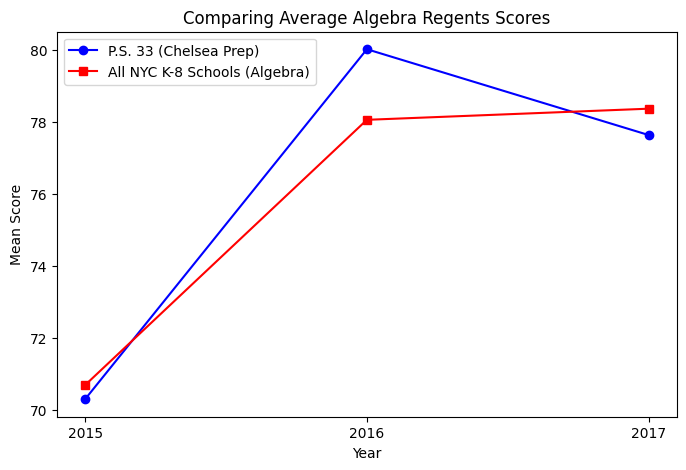

In [64]:
fig, ax = plt.subplots(figsize=(8, 5))

# Group and calculate mean for each dataset
df2_yearly = df2.groupby('Year')['Mean Score'].mean()
df4_yearly = df4.groupby('Year')['Mean Score'].mean()

# Plot the averaged scores over the years
df2_yearly.plot(kind='line', marker='o', ax=ax, label='P.S. 33 (Chelsea Prep)', color='blue')
df4_yearly.plot(kind='line', marker='s', ax=ax, label='All NYC K-8 Schools (Algebra)', color='red')

ax.set_title('Comparing Average Algebra Regents Scores')
ax.set_xlabel('Year')
ax.set_ylabel('Mean Score')
ax.set_xticks([2015, 2016, 2017])
ax.legend()
plt.show()

comparing median of PS 33 with all schools

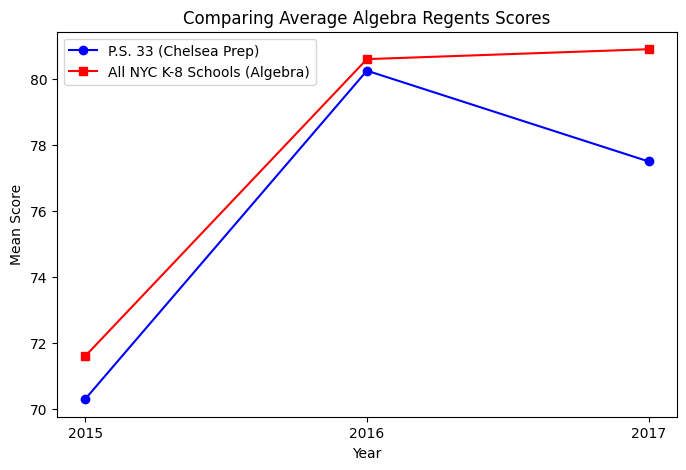

In [65]:
fig, ax = plt.subplots(figsize=(8, 5))

# Group and calculate mean for each dataset
df2_yearly = df2.groupby('Year')['Mean Score'].median()
df4_yearly = df4.groupby('Year')['Mean Score'].median()

# Plot the averaged scores over the years
df2_yearly.plot(kind='line', marker='o', ax=ax, label='P.S. 33 (Chelsea Prep)', color='blue')
df4_yearly.plot(kind='line', marker='s', ax=ax, label='All NYC K-8 Schools (Algebra)', color='red')

ax.set_title('Comparing Median Algebra Regents Scores')
ax.set_xlabel('Year')
ax.set_ylabel('Median Score')
ax.set_xticks([2015, 2016, 2017])
ax.legend()
plt.show()

In [ ]:
Conclusion: Graph shows PS 33 median score in algebra is below the median values across other K-8 in algebra.